# **PROYECTO INTEGRADOR DE DOMINIO AUTÓNOMO (PIDA)**
---

*The Learning Gate*
*   NOMBRE DEL PARTICIPANTE: Amaury Félix Díaz
*   PROYECTO: Procesamiento de lenguaje natural y análisis de sentimientos aplicado a la percepción estudiantil

---
`PROPÓSITO DE LA CERTIFICACIÓN:` Evaluar, mediante un proyecto que el conjunto de competencias adquiridas en el programa de entrenamiento genere en la organización y/o persona, un impacto de mejora medible, claramente estructurado y autogestionado por parte del participante.

## **ETAPA I:** Entendimiento del negocio
Esta etapa consiste en definir el alcance del proyecto, considerando los objetivos comerciales, para evaluar con mayor precisión el impacto del proyecto en la empresa/organización.

* **Antecedentes:** ¿En qué empresa/organización se desarrolla el proyecto? ¿Cuál o cuáles son los proceso o procesos de negocios que serán impactados por el mismo?

La Universidad Nacional Autónoma de México, al final de cada ciclo escolar proporciona al alumnado un instrumento de percepción estudiantil, en el cual evalúa algunos aspectos de los profesores y las clases que tomaron durante todo el ciclo. Este instrumento evalúa aspectos importantes como la calidad de la enseñanza o el contenido que el profesor impartió, así como otros puntos como proporcionar y respetar un método de evaluación o seguir el plan de estudios.
Este modelo busca simular una predicción sobre la reinscripción de los alumnos a alguna clase del profesor que se evalúa y asignarle un score al mismo profesor, a través de un modelo de clasificación y de regresión.

* **Formulación del problema:** ¿Qué es lo que se intenta resolver?

La universidad recibe millones de reseñas y evaluaciones sobre los profesores, es muy complicado analizar los resultados de cada uno de los profesores y con este modelo se busca agilizar y automatizar esta tarea, obteniendo reportes más detallados y generales sobre los profesores.

* **Valor agregado:** ¿Por qué es importante resolver este problema?

Es importante mejorar la calidad de la enseñanza en toda la universidad y con esta herramienta podemos obtener resultados más detallados y resumidos sobre los profesores que imparten la clase, de esta forma se pueden atacar las áreas en donde flaquean los profesores y en las que los alumnos quieren que mejoren.

* **Objetivos:** ¿Cuál es la meta prevista? ¿Cuál(es) es(son) los criterios de éxito?

Se busca obtener un score que concuerde con los comentarios y las métricas que cada profesor tiene para poder estimar si los alumnos volvería a reinscribirse a alguna de sus clases.
Se busca que la precisión del modelo sea de más del 80%.

* **Diccionario de datos:** ¿Qué representa cada variable?
* original_text: La reseña escrita por los estudiantes
* translate_text: Una traducción al inglés de la reseña
* mp_tag: Una clasificación que los estudiantes colocan sobre el profesor
* subject: La materia que impartió el profesor
* date: La fecha en la que se escribió la reseña

* **Predictores y respuesta:** ¿Cuáles son las entradas y la(s) salida(s)?

La entrada es la reseña y la salida es la clasificación (mp_tag) y el score que genera el modelo.

## **ETAPA II:** Entendimiento de los datos

Esta etapa consiste en la ingestión o recopilación de los datos y su exploración, mediante estadísticas descriptiva e inferencial y visualizaciones concluyentes.

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# Verificar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Cargar el modelo y el tokenizador BETO base
modelo_beto = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(modelo_beto)
model = AutoModelForSequenceClassification.from_pretrained(modelo_beto, num_labels = 3).to(device)

Usando dispositivo: cuda


C:\Users\amaur\anaconda3\envs\beto_env\lib\site-packages\transformers\modeling_utils.py:519: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(checkpoint_file,

In [ ]:
# Cargar el CSV
df = pd.read_csv("MPCorpus_unlabeled.csv")

print(df)

                                           original_text  \
0      Las clases están de ueba y deja tareas bien pa...   
1      No escucha cuando le hablas  o le dices presen...   
2                                            desobligada   
3      Excelente profesor comprometido y con interés ...   
4      Su clase era muy confusa y muy aburrida A vece...   
...                                                  ...   
18042              Excelente doctora y muy buena persona   
18043                  Muy buena y muy humana la doctora   
18044  El peor docente de medicina Solo he aprendido ...   
18045                        El peor docente de medicina   
18046  Es un docente que solo se basa en la participa...   

                                          translate_text   mp_tag  \
0      The classes are in ueba and leaves well past t...  REGULAR   
1      He doesn't listen when you talk to him or you ...  REGULAR   
2                                            unobligated     MALO   
3  

In [ ]:
# Mapear etiquetas a números
etiquetas = {"MALO": 0, "REGULAR": 1, "BUENO": 2}
df["label"] = df["mp_tag"].map(etiquetas)

# Crear dataset de HuggingFace
dataset = Dataset.from_pandas(df)

# Dividir en entrenamiento y prueba
dataset = dataset.train_test_split(test_size = 0.2, seed = 42)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['original_text', 'translate_text', 'mp_tag', 'subject', 'date', 'label'],
        num_rows: 14437
    })
    test: Dataset({
        features: ['original_text', 'translate_text', 'mp_tag', 'subject', 'date', 'label'],
        num_rows: 3610
    })
})


In [ ]:
print("Dimensiones (filas, columnas):", df.shape)
display(df.head(5))

Dimensiones (filas, columnas): (18047, 6)


,original_text,translate_text,mp_tag,subject,date,label
0,Las clases están de ueba y deja tareas bien pa...,The classes are in ueba and leaves well past t...,REGULAR,Álgebra Lineal,12/Mar/2023,1
1,No escucha cuando le hablas o le dices presen...,He doesn't listen when you talk to him or you ...,REGULAR,Algebra Lineal,17/Feb/2022,1
2,desobligada,unobligated,MALO,inv de ops,16/Dic/2020,0
3,Excelente profesor comprometido y con interés ...,Excellent teacher committed and with interest ...,BUENO,Ética Profesional,27/Feb/2020,2
4,Su clase era muy confusa y muy aburrida A vece...,His class was very confusing and very boring S...,MALO,Historia de la filosofía I,17/Dic/2019,0


In [ ]:
n_filas, n_cols = df.shape
print(f"Dimensionalidad del dataset: {n_filas} filas x {n_cols} columnas")
print("\nColumnas disponibles:")
print(df.columns.tolist())

Dimensionalidad del dataset: 18047 filas x 6 columnas

Columnas disponibles:
['original_text', 'translate_text', 'mp_tag', 'subject', 'date', 'label']


In [ ]:
print("Tipos de datos (dtypes):")
print(df.dtypes)

# Intentar convertir a fecha si existe una columna de fecha
for col in df.columns:
    if col.lower() in ("date", "fecha"):
        try:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print(f"\nColumna '{col}' convertida a tipo datetime. Ejemplo de valores:")
            display(df[[col]].head())
        except Exception as e:
            print(f"No se pudo convertir '{col}' a datetime: {e}")

Tipos de datos (dtypes):
original_text     object
translate_text    object
mp_tag            object
subject           object
date              object
label              int64
dtype: object

Columna 'date' convertida a tipo datetime. Ejemplo de valores:


,date
0,2023-03-12
1,2022-02-17
2,NaT
3,2020-02-27
4,NaT


In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
missing_table = pd.DataFrame({
    "nulos": nulos,
    "porcentaje": pct_nulos.round(2)
}).sort_values(by = "nulos", ascending = False)

display(missing_table)

# Mostrar columnas con valores faltantes
if missing_table["nulos"].sum() > 0:
    print("\nColumnas con valores faltantes:")
    display(missing_table[missing_table["nulos"] > 0])
else:
    print("\nNo se detectaron valores faltantes en el dataset.")

,nulos,porcentaje
date,6517,36.11
translate_text,8,0.04
original_text,0,0.00
mp_tag,0,0.00
subject,0,0.00
label,0,0.00



Columnas con valores faltantes:


,nulos,porcentaje
date,6517,36.11
translate_text,8,0.04


In [ ]:
print("Estadísticas de columnas numéricas:")
display(df.describe(include = ['number']).T)

# 5.2 Categóricas / de texto
print("\nEstadísticas de columnas no numéricas:")
display(df.describe(include = ['object', 'category']).T)

# 5.3 Longitud de reseñas si existe 'original_text'
if 'original_text' in df.columns:
    df['len_chars'] = df['original_text'].astype(str).apply(len)
    df['len_words'] = df['original_text'].astype(str).apply(lambda s: len(s.split()))
    print("\nEstadísticas de longitud de reseñas:")
    display(df[['len_chars', 'len_words']].describe().T)
else:
    print("\nNo se encontró la columna 'original_text'.")

Estadísticas de columnas numéricas:


,count,mean,std,min,25%,50%,75%,max
label,18047.0,1.388929,0.831375,0.0,1.0,2.0,2.0,2.0



Estadísticas de columnas no numéricas:


,count,unique,top,freq
original_text,18047,17206,Excelente profesor,67
translate_text,18039,17087,Excellent teacher,72
mp_tag,18047,3,BUENO,11111
subject,18047,9493,Ecuaciones Diferenciales,76



Estadísticas de longitud de reseñas:


,count,mean,std,min,25%,50%,75%,max
len_chars,18047.0,142.293401,92.949200,5.0,61.0,130.0,220.0,496.0
len_words,18047.0,25.804566,17.157296,1.0,11.0,23.0,40.0,98.0


In [ ]:
cardinalidad = df.nunique().sort_values(ascending = False)
display(cardinalidad.to_frame("valores_únicos"))

cols_categoricas = [c for c in df.columns if df[c].dtype == 'object' and df[c].nunique() < 200]
print("\nColumnas categóricas candidatas:", cols_categoricas)

for col in cols_categoricas:
    print(f"\nTop valores en '{col}':")
    display(df[col].value_counts(dropna = False).head(10))

,valores_únicos
original_text,17206
translate_text,17087
subject,9493
date,2967
len_chars,398
len_words,94
mp_tag,3
label,3



Columnas categóricas candidatas: ['mp_tag']

Top valores en 'mp_tag':


mp_tag
BUENO      11111
MALO        4092
REGULAR     2844
Name: count, dtype: int64

In [ ]:
if 'original_text' in df.columns:
    duplicados = df['original_text'].duplicated().sum()
    print(f"Duplicados exactos en 'original_text': {duplicados}")
    if duplicados > 0:
        print("\nEjemplos de textos duplicados:")
        display(df[df['original_text'].duplicated(keep=False)].head(10))
else:
    print("No se encontró la columna 'original_text'.")

Duplicados exactos en 'original_text': 841

Ejemplos de textos duplicados:


,original_text,translate_text,mp_tag,subject,date,label,len_chars,len_words
27,Muy buena,Very good.,BUENO,Sistema,NaT,2,9,2
58,excelente,excellent.,BUENO,arquitectura,2011-06-20,2,9,1
69,Excelente maestra,Excellent teacher,BUENO,Derecho I,2012-06-06,2,17,2
94,Muy buena maestra,Very good teacher,BUENO,Prescripción médica,2023-03-10,2,17,3
95,excelente profesor,excellent teacher,BUENO,propedeutica,2015-11-27,2,18,2
97,Excelente,Excellent.,BUENO,Fisiopatologia,2015-02-28,2,9,1
104,Excelente profesor,Excellent teacher.,BUENO,Anatomía e Histologia,2017-05-17,2,18,2
109,Excelente profesor,Excellent teacher.,BUENO,Programación de operaciones,2016-09-28,2,18,2
111,buena profesora,good teacher,BUENO,taller,2010-07-29,2,15,2
112,mmmmquién se oonfundirá en las definiciones us...,hmmmm who will hear in the definitions you or ...,BUENO,varias,2010-07-14,2,278,50


In [ ]:
df = df.drop_duplicates(subset = "original_text")
df = df.dropna(subset = ["original_text", "mp_tag"])

C:\Users\amaur\AppData\Local\Temp\ipykernel_22560\2457636759.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = df[target_col], order = df[target_col].value_counts().index, palette = "Set2")


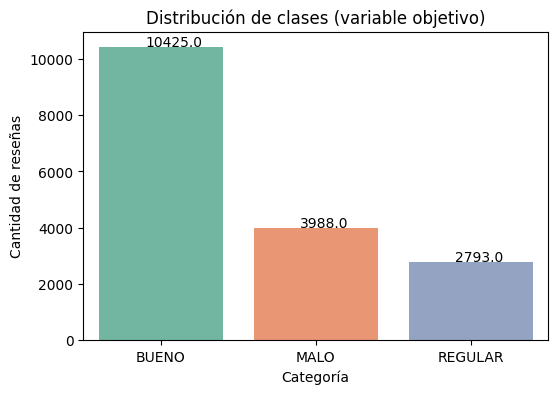

In [ ]:
target_col = "mp_tag"

if target_col in df.columns:
    plt.figure(figsize = (6, 4))
    ax = sns.countplot(x = df[target_col], order = df[target_col].value_counts().index, palette = "Set2")
    plt.title("Distribución de clases (variable objetivo)")
    plt.xlabel("Categoría")
    plt.ylabel("Cantidad de reseñas")
    for p in ax.patches:
        ax.annotate(f"{p.get_height()}", (p.get_x()+0.3, p.get_height()+5))
    plt.show()
else:
    print(f"No se encontró la columna '{target_col}'.")

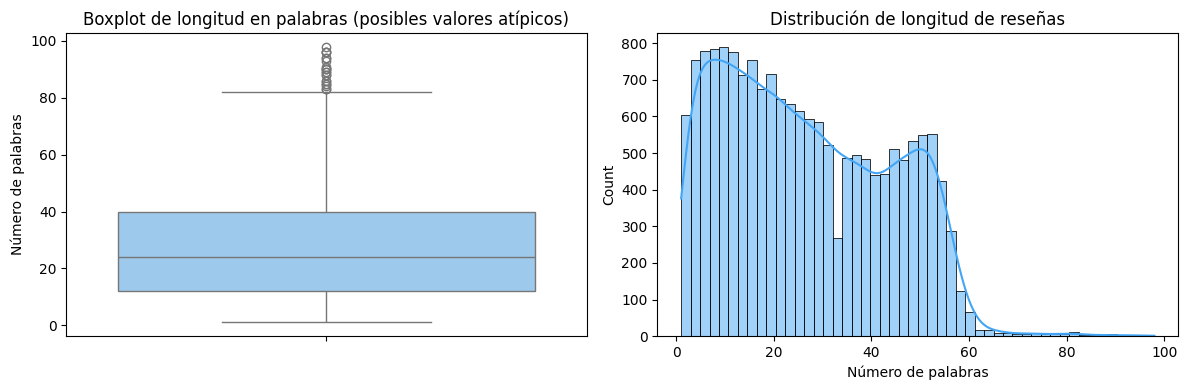

In [ ]:
if "original_text" in df.columns:
    df["len_chars"] = df["original_text"].astype(str).apply(len)
    df["len_words"] = df["original_text"].astype(str).apply(lambda s: len(s.split()))

    fig, axes = plt.subplots(1, 2, figsize = (12, 4))

    sns.boxplot(y = df["len_words"], ax = axes[0], color = "#90CAF9")
    axes[0].set_title("Boxplot de longitud en palabras (posibles valores atípicos)")
    axes[0].set_ylabel("Número de palabras")

    sns.histplot(df["len_words"], bins = 50, kde = True, ax = axes[1], color = "#42A5F5")
    axes[1].set_title("Distribución de longitud de reseñas")
    axes[1].set_xlabel("Número de palabras")

    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la columna 'original_text'.")

C:\Users\amaur\AppData\Local\Temp\ipykernel_22560\3943188451.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="mp_tag", y="len_words", data=df, palette="Set3")


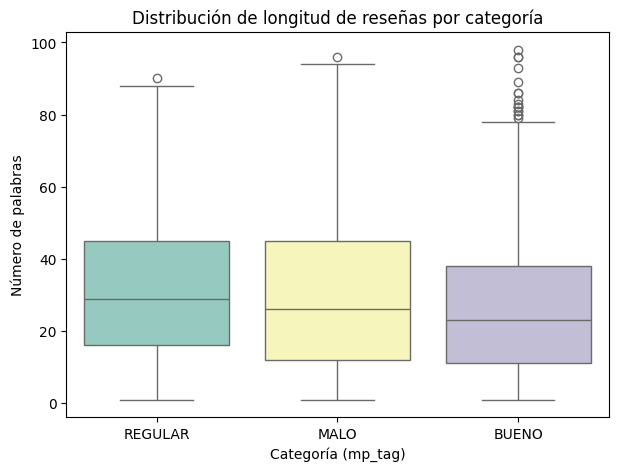

In [ ]:
if "mp_tag" in df.columns and "len_words" in df.columns:
    plt.figure(figsize = (7, 5))
    sns.boxplot(x = "mp_tag", y = "len_words", data = df, palette = "Set3")
    plt.title("Distribución de longitud de reseñas por categoría")
    plt.xlabel("Categoría (mp_tag)")
    plt.ylabel("Número de palabras")
    plt.show()
else:
    print("Faltan columnas 'mp_tag' o 'len_words' para este gráfico.")

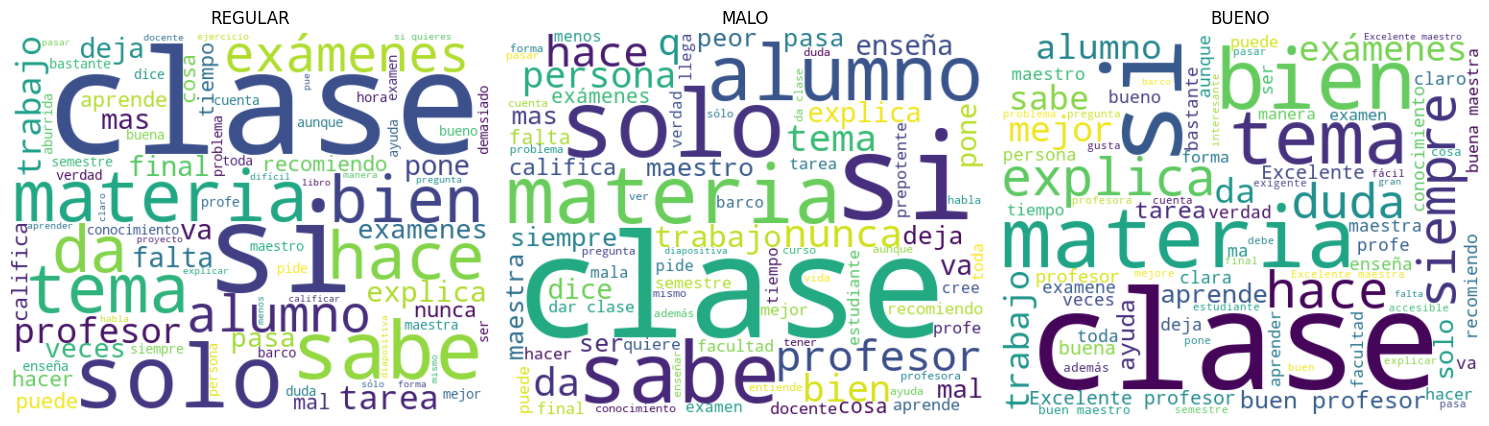

In [ ]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet = True)
stopwords_es = set(stopwords.words("spanish"))

if "mp_tag" in df.columns and "original_text" in df.columns:
    categorias = df["mp_tag"].unique()
    fig, axes = plt.subplots(1, len(categorias), figsize = (5 * len(categorias), 5))
    if len(categorias) == 1:
        axes = [axes]
    for i, cat in enumerate(categorias):
        texto = " ".join(df[df["mp_tag"] == cat]["original_text"].astype(str))
        wc = WordCloud(
            width = 500, height = 400, background_color = "white",
            stopwords = stopwords_es, colormap = "viridis", max_words = 80
        ).generate(texto)
        axes[i].imshow(wc, interpolation = "bilinear")
        axes[i].axis("off")
        axes[i].set_title(cat)
    plt.tight_layout()
    plt.show()
else:
    print("Faltan columnas 'mp_tag' u 'original_text' para generar nubes de palabras.")

**CONCLUSIONES:** ¿Cuáles son los hallazgos más importantes del análisis exploratorio de datos?

A traves del análisis exploratorio de los datos podemos notar algunos patrones entre las reseñas y las etiquetas que se les da a los profesores podemos notar algunos patrones.
En primera, podemos notar una desigualdad entre los datos, ya que predominan las reseñas hacia buenos profesores (lo cual sería un buen indicador) y probablemente esto incline nuestro modelo a clasificar en su mayoría todas las reseñas como buenas (también dependería de la calidad de la reseña), también podemos darnos cuenta de que la categoría que cuenta con más registros después de "bueno", es la categoría "malo" y hace sentido, ya que muchas veces nos inclinamos a clasificar las cosas como buenas o malas, evitamos caer en la mitad de la recta, así como muestra la distribución de los datos.
Curiosamente, la longitud de palabras y carácteres es distinta, los alumnos tienden a hacer reseñas más cortas para los profesores buenos, suponiendo que no tienen mucho que decir más que les agradó la clase y la manera de enseñar de los profesores, podemos notar muchos valores atípicos, esto significa que algunos alumnos sí se esforzaron en distinguir a los profesores que les brindaron una buena experiencia académica; notamos que los alumnos que clasificaron como regulares a los profesores realizaron reseñas más largas, esto puede deberse a que sus comentarios se centran en qué le faltó al profesor para que la clase pudiera ser mejor o algo que hicieron que les arruinó la experiencia; las reseñas malas se centran justo en la mitad con algunos valores atípicos, probablemente los alumnos no tuvieron mucho que decir sobre la mala experiencia que tuvieron y varios de ellos sí expresaron la frustración que sintieron tomando la clase.

## **ETAPA III:** Preparación de los datos

En esta etapa se aplican operaciones comunes para convertir los datos crudos del mundo real, en un conjunto de variables útiles para el aprendizaje automático.

In [ ]:
def tokenizar(batch):
    return tokenizer(batch["original_text"], padding = "max_length", truncation = True, max_length = 128)

dataset_tokenizado = dataset.map(tokenizar, batched = True)
dataset_tokenizado = dataset_tokenizado.remove_columns(["original_text", "translate_text", "mp_tag", "subject", "date"])
dataset_tokenizado.set_format("torch")

Map:   0%|          | 0/14437 [00:00<?, ? examples/s]

Map:   0%|          | 0/3610 [00:00<?, ? examples/s]

**CONCLUSIONES:** Enumerar y justificar las decisiones y técnicas empleadas.

Se realizó una limpieza de duplicados y de valores nulos, pero la parte más importante de la preparación de datos fua una tokenización, usando el tokenizador del modelo BETO, el cual convierte cada reseña en una secuencia numérica de tokens y que el modelo pueda analizarlos de mejor manera. Finalmente se realizó una división en un conjunto de prueba y otro de entrenamiento, transformando los textos en tensores de entrada compatibles con el modelo.

## **ETAPA IV:** Modelación y evaluación del modelo

En esta etapa se construyen y evalúan varios modelos usando diversos algoritmos. En caso de que los resultados sean deficientes, la metodología permite volver al primer paso para tener una comprensión de lo que está ocurriendo.

In [ ]:
metric = evaluate.combine(["accuracy", "precision", "recall", "f1"])

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = 1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


training_args = TrainingArguments(
    output_dir = "./results",
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 3e-5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    num_train_epochs = 6,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = "f1",
    greater_is_better = True,
    logging_dir = "./logs",
    logging_strategy = "epoch",
    fp16 = torch.cuda.is_available(),
    report_to = "none"
)

In [ ]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = dataset_tokenizado["train"],
    eval_dataset = dataset_tokenizado["test"],
    tokenizer = tokenizer,
    compute_metrics = compute_metrics,
)

trainer.train()

C:\Users\amaur\anaconda3\envs\beto_env\lib\site-packages\accelerate\accelerator.py:449: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.523600,0.460847,0.804432,0.792688,0.804432,0.789379
2,0.380800,0.554317,0.809972,0.792169,0.809972,0.796818
3,0.255300,0.649745,0.806925,0.798446,0.806925,0.802102
4,0.147700,0.874289,0.795845,0.793705,0.795845,0.794610
5,0.082300,1.120118,0.800831,0.800196,0.800831,0.800511
6,0.047000,1.266445,0.793906,0.796774,0.793906,0.795160


TrainOutput(global_step=5418, training_loss=0.2394386874480897, metrics={'train_runtime': 21661.0752, 'train_samples_per_second': 3.999, 'train_steps_per_second': 0.25, 'total_flos': 5697852617608704.0, 'train_loss': 0.2394386874480897, 'epoch': 6.0})

In [ ]:
# Definir conjuntos de datos explícitamente
train_dataset = dataset_tokenizado["train"]
test_dataset = dataset_tokenizado["test"]

# Obtener predicciones
predicciones = trainer.predict(test_dataset)

In [ ]:
# Obtener predicciones del conjunto de prueba
predicciones = trainer.predict(test_dataset)

# Extraer etiquetas verdaderas y predichas
y_true = np.array(predicciones.label_ids)
y_pred = np.argmax(predicciones.predictions, axis = 1)

In [ ]:
# Crear reporte de métricas
reporte = classification_report(y_true, y_pred, target_names = ["Malo", "Regular", "Bueno"], output_dict = True)
df_reporte = pd.DataFrame(reporte).transpose()

print("Métricas generales del modelo:")
display(df_reporte)

Métricas generales del modelo:


,precision,recall,f1-score,support
Malo,0.726303,0.767209,0.746196,799.000000
Regular,0.441304,0.373849,0.404786,543.000000
Bueno,0.909367,0.924603,0.916922,2268.000000
accuracy,0.806925,0.806925,0.806925,0.806925
macro avg,0.692325,0.688554,0.689301,3610.000000
weighted avg,0.798446,0.806925,0.802102,3610.000000


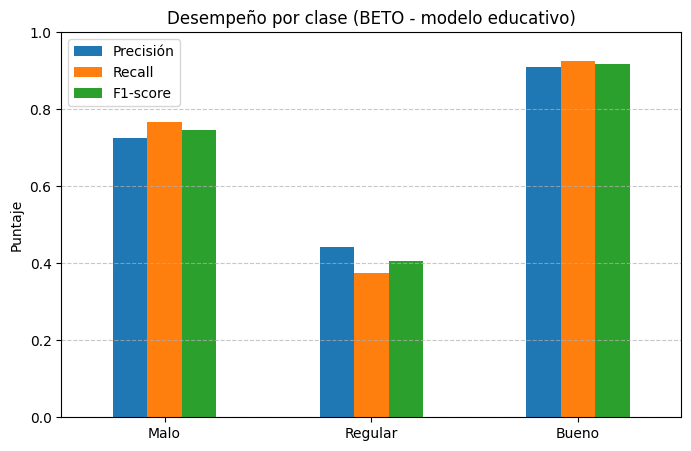

In [ ]:
# Gráfico de F1, Precisión y Recall por clase
fig, ax = plt.subplots(figsize = (8, 5))

df_reporte.loc[["Malo", "Regular", "Bueno"], ["precision", "recall", "f1-score"]].plot.bar(ax = ax)
plt.title("Desempeño por clase (BETO - modelo educativo)")
plt.ylabel("Puntaje")
plt.ylim(0, 1)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.xticks(rotation = 0)
plt.legend(["Precisión", "Recall", "F1-score"])
plt.show()

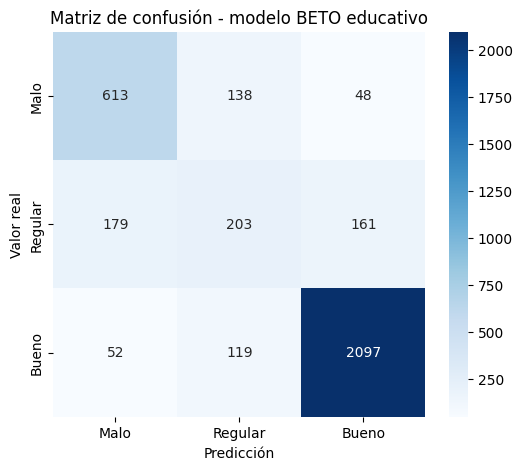

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
labels = ["Malo", "Regular", "Bueno"]

plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = labels, yticklabels = labels)
plt.title("Matriz de confusión - modelo BETO educativo")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

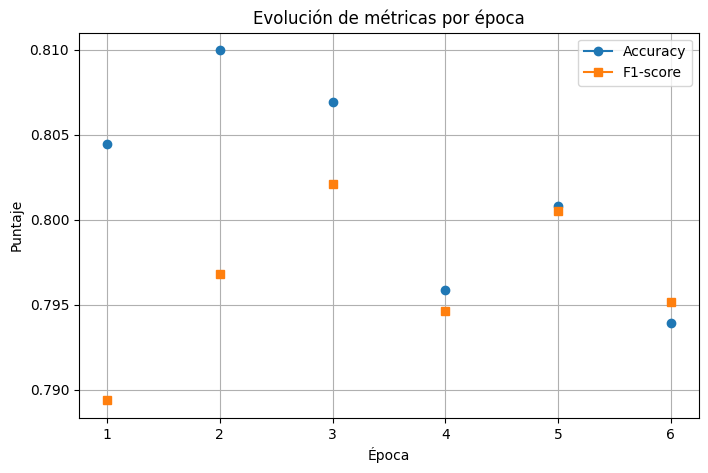

In [ ]:
history = pd.DataFrame(trainer.state.log_history)
epochs = history.dropna(subset = ["epoch"])

plt.figure(figsize = (8,5))
plt.plot(epochs["epoch"], epochs["eval_accuracy"], marker = "o", label = "Accuracy")
plt.plot(epochs["epoch"], epochs["eval_f1"], marker = "s", label = "F1-score")
plt.title("Evolución de métricas por época")
plt.xlabel("Época")
plt.ylabel("Puntaje")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_metrics = {
    "Exactitud (Accuracy)": df_reporte.loc["accuracy", "f1-score"],
    "F1 global": df_reporte.loc["weighted avg", "f1-score"],
    "Precisión promedio": df_reporte.loc["weighted avg", "precision"],
    "Recall promedio": df_reporte.loc["weighted avg", "recall"]
}

print("\nResumen final del modelo BETO educativo:\n")
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.4f}")


Resumen final del modelo BETO educativo:

Exactitud (Accuracy): 0.8069
F1 global: 0.8021
Precisión promedio: 0.7984
Recall promedio: 0.8069


In [ ]:
# Evaluación final
resultados = trainer.evaluate()
print(resultados)

# Guardar modelo y tokenizador
trainer.save_model("./modelo_beto_educativo")
tokenizer.save_pretrained("./modelo_beto_educativo")

{'eval_loss': 0.6497445106506348, 'eval_accuracy': 0.8069252077562327, 'eval_precision': 0.7984456151127558, 'eval_recall': 0.8069252077562327, 'eval_f1': 0.8021018508786394, 'eval_runtime': 225.5786, 'eval_samples_per_second': 16.003, 'eval_steps_per_second': 1.002, 'epoch': 6.0}


('./modelo_beto_educativo\\tokenizer_config.json',
 './modelo_beto_educativo\\special_tokens_map.json',
 './modelo_beto_educativo\\vocab.txt',
 './modelo_beto_educativo\\added_tokens.json',
 './modelo_beto_educativo\\tokenizer.json')

In [ ]:
from transformers import pipeline

clasificador = pipeline(
    "text-classification",
    model = "./modelo_beto_educativo",
    tokenizer = "./modelo_beto_educativo",
    device = 0 if torch.cuda.is_available() else -1
)

textos = [
    "El profesor fue muy paciente y explicó bien",
    "La clase fue muy aburrida y poco clara",
    "No estuvo mal, pero podría mejorar"
]

for t in textos:
    print(f"{t} -> {clasificador(t)}")

El profesor fue muy paciente y explicó bien -> [{'label': 'LABEL_2', 'score': 0.9962426424026489}]
La clase fue muy aburrida y poco clara -> [{'label': 'LABEL_1', 'score': 0.7453804016113281}]
No estuvo mal, pero podría mejorar -> [{'label': 'LABEL_2', 'score': 0.7427427768707275}]


In [ ]:
# Cargar el modelo entrenado
clasificador = pipeline(
    "text-classification",
    model = "./modelo_beto_educativo",
    tokenizer = "./modelo_beto_educativo",
    device = 0 if torch.cuda.is_available() else -1
)

# Diccionario para interpretar las etiquetas del modelo
mapa_etiquetas = {
    "LABEL_0": "Malo",
    "LABEL_1": "Regular",
    "LABEL_2": "Bueno"
}

# Función para estimar si el alumno se reinscribiría
def predecir_reinscripcion(label, score):
    if label == "LABEL_2" and score > 0.6:
        return "Alta probabilidad de reinscripción"
    elif label == "LABEL_1" and score > 0.6:
        return "Probabilidad moderada de reinscripción"
    else:
        return "Baja probabilidad de reinscripción"

# Lista de reseñas nuevas
reseñas = [
    "El profesor fue muy amable y siempre resolvía mis dudas.",
    "Las clases eran muy confusas y aburridas.",
    "El curso estuvo bien, pero podría mejorar en la organización.",
    "Excelente experiencia, aprendí muchísimo.",
    "No me gustó la forma de evaluar."
]

# Analizar reseñas una por una
for texto in reseñas:
    resultado = clasificador(texto)[0]
    label = resultado["label"]
    score = round(resultado["score"], 3)
    clasificacion = mapa_etiquetas[label]
    reinscripcion = predecir_reinscripcion(label, score)

    print(f"Reseña: \"{texto}\"")
    print(f"Clasificación: {clasificacion}")
    print(f"Score: {score}")
    print(f"Predicción: {reinscripcion}")
    print("-" * 90)

Reseña: "El profesor fue muy amable y siempre resolvía mis dudas."
Clasificación: Bueno
Score: 0.998
Predicción: Alta probabilidad de reinscripción
------------------------------------------------------------------------------------------
Reseña: "Las clases eran muy confusas y aburridas."
Clasificación: Regular
Score: 0.879
Predicción: Probabilidad moderada de reinscripción
------------------------------------------------------------------------------------------
Reseña: "El curso estuvo bien, pero podría mejorar en la organización."
Clasificación: Bueno
Score: 0.948
Predicción: Alta probabilidad de reinscripción
------------------------------------------------------------------------------------------
Reseña: "Excelente experiencia, aprendí muchísimo."
Clasificación: Bueno
Score: 0.998
Predicción: Alta probabilidad de reinscripción
------------------------------------------------------------------------------------------
Reseña: "No me gustó la forma de evaluar."
Clasificación: Regul

**CONCLUSIONES**: ¿El rendimiento del modelo es lo suficientemente bueno para su implementación en producción? ¿Existe margen para mejorarlo? ¿Cuáles serían las recomendaciones clave para poder implementar la solución?

Sí, considero que el modelo funciona bastante bien tomando en cuenta que las reseñas son muy complicadas de analizar, a veces porque no se entiende todo el contexto y porque los alumnos muchas veces no son claros a la hora de escribir, sin tomar en cuenta faltas de ortografía o errores de redacción.
Notamos que el modelo tiende a equivocarse en reseñas que catalogan al profesor como regular, ya que es más complicado para el modelo quedarse en un punto medio, muchas veces tiene a clasificar en 0's y 1's.
La posibilidad de mejorar el acuraccy del modelo radica en los parámetros y en la capacidad de la computadora para realizar el entrenamiento de redes neuronales.